# FLS Marine Debris 
This dataset is found here: https://github.com/mvaldenegro/marine-debris-fls-datasets. It is described in this paper: https://arxiv.org/abs/2108.06800

This .ipynb file was used to set up the data on the ultralytics YOLO format. This setup includes unzipping, setting up folders/paths and making yaml setup file, and also confirming the data and visualizing it. 

## Setting up data

In [3]:
# Unzipping

import tarfile, os

src = "marine-debris-watertank-release-1.0.tar.xz"
out_dir = "extracted"
os.makedirs(out_dir, exist_ok=True)

with tarfile.open(src, mode="r:xz") as tar:
    tar.extractall(out_dir)

print("Extracted to:", out_dir)

/usr/lib64/python3.9/tarfile.py:2268: RuntimeWarning: The default behavior of tarfile extraction has been changed to disallow common exploits (including CVE-2007-4559). By default, absolute/parent paths are disallowed and some mode bits are cleared. See https://access.redhat.com/articles/7004769 for more details.
  warnings.warn(


Extracted to: extracted


In [4]:
# labels from .json to .txt files

from pathlib import Path
import json
from PIL import Image

# --- paths (adjust if yours differs) ---
release_dir = Path("extracted/marine-debris-watertank-release")
img_dir = release_dir / "fls-images"
ann_json_path = img_dir / "annotations.json"

# output folder: extracted/marine-debris-watertank-release/annotations
out_dir = release_dir / "annotations"
out_dir.mkdir(parents=True, exist_ok=True)

# --- load json ---
with open(ann_json_path, "r") as f:
    ann = json.load(f)

def clamp01(x: float) -> float:
    return max(0.0, min(1.0, x))

written = 0
missing_images = 0

# Create labels for every image mentioned in the JSON
for img_name, info in ann.items():
    img_path = img_dir / img_name
    if not img_path.exists():
        missing_images += 1
        continue

    # get image size for normalization
    with Image.open(img_path) as im:
        W, H = im.size

    lines = []
    for box in info.get("bounding-boxes", []):
        cls = int(box["class-id"])
        x = float(box["top-left-x"])
        y = float(box["top-left-y"])
        w = float(box["width"])
        h = float(box["height"])

        # YOLO: x_center y_center width height (normalized)
        x_c = (x + w / 2.0) / W
        y_c = (y + h / 2.0) / H
        w_n = w / W
        h_n = h / H

        # (optional) clamp to [0,1] to avoid invalid values
        x_c, y_c, w_n, h_n = map(clamp01, (x_c, y_c, w_n, h_n))

        lines.append(f"{cls} {x_c:.6f} {y_c:.6f} {w_n:.6f} {h_n:.6f}")

    # write .txt with same stem as image
    label_path = out_dir / (Path(img_name).stem + ".txt")
    label_path.write_text("\n".join(lines) + ("\n" if lines else ""))

    written += 1

print(f"Done. Wrote {written} label files to: {out_dir}")
if missing_images:
    print(f"Warning: {missing_images} images listed in JSON were not found on disk.")

Done. Wrote 1868 label files to: extracted/marine-debris-watertank-release/annotations


In [1]:
# Making train/val/test split like in the paper

from pathlib import Path
import shutil, random
import numpy as np
from PIL import Image

# ---------------- Paths ----------------
root = Path(".")  # same folder as your .ipynb
release_dir = root / "extracted" / "marine-debris-watertank-release"
img_dir = release_dir / "fls-images"
label_dir = release_dir / "annotations"   # created earlier

processed = root / "processed"
out_img = processed / "images"
out_lbl = processed / "labels"

# ---------------- Collect images ----------------
images = sorted(img_dir.glob("*.png"))
N = len(images)
print("Found images:", N)

# desired split sizes (as per your description)
n_train, n_val, n_test = 1000, 251, 617

if N != (n_train + n_val + n_test):
    raise ValueError(f"Expected {n_train+n_val+n_test} images (=1868) but found {N}. "
                     "Check your folder or adjust n_train/n_val/n_test.")

# ---------------- Precompute per-image features: object counts + pixel area per class ----------------
# First pass: find max class id
max_cls = -1
label_paths = []
for p in images:
    lp = label_dir / (p.stem + ".txt")
    label_paths.append(lp)
    if lp.exists():
        for line in lp.read_text().strip().splitlines():
            if not line.strip():
                continue
            cls = int(line.split()[0])
            max_cls = max(max_cls, cls)

C = max_cls + 1
print("Detected classes:", C)

obj = np.zeros((N, C), dtype=np.int32)      # object counts per image per class
area = np.zeros((N, C), dtype=np.float64)   # pixel-area sum per image per class

# cache image sizes (needed for pixel areas)
sizes = []
for i, p in enumerate(images):
    with Image.open(p) as im:
        W, H = im.size
    sizes.append((W, H))

    lp = label_paths[i]
    if not lp.exists():
        continue

    txt = lp.read_text().strip()
    if not txt:
        continue

    for line in txt.splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls = int(parts[0])
        x_c, y_c, w_n, h_n = map(float, parts[1:])

        obj[i, cls] += 1
        # YOLO width/height are normalized; convert to pixel area
        box_w = w_n * W
        box_h = h_n * H
        area[i, cls] += (box_w * box_h)

total_obj = obj.sum(axis=0)
total_area = area.sum(axis=0)

# ---------------- Scoring: how well do splits match per-class distributions? ----------------
def score_split(train_idx, val_idx, test_idx):
    # sums per split
    o_tr = obj[train_idx].sum(axis=0)
    o_va = obj[val_idx].sum(axis=0)
    o_te = obj[test_idx].sum(axis=0)

    a_tr = area[train_idx].sum(axis=0)
    a_va = area[val_idx].sum(axis=0)
    a_te = area[test_idx].sum(axis=0)

    # expected (by fraction of images)
    f_tr = len(train_idx) / N
    f_va = len(val_idx) / N
    f_te = len(test_idx) / N

    eps = 1e-9
    s = 0.0

    for c in range(C):
        if total_obj[c] > 0:
            e_tr = total_obj[c] * f_tr
            e_va = total_obj[c] * f_va
            e_te = total_obj[c] * f_te
            # relative squared error on object counts
            s += ((o_tr[c]-e_tr)/(e_tr+eps))**2
            s += ((o_va[c]-e_va)/(e_va+eps))**2
            s += ((o_te[c]-e_te)/(e_te+eps))**2
            # penalty if a class disappears from a split
            if o_tr[c] == 0: s += 2.0
            if o_va[c] == 0: s += 2.0
            if o_te[c] == 0: s += 2.0

        if total_area[c] > 0:
            ea_tr = total_area[c] * f_tr
            ea_va = total_area[c] * f_va
            ea_te = total_area[c] * f_te
            # relative squared error on pixel area
            s += ((a_tr[c]-ea_tr)/(ea_tr+eps))**2
            s += ((a_va[c]-ea_va)/(ea_va+eps))**2
            s += ((a_te[c]-ea_te)/(ea_te+eps))**2

    return float(s)

# ---------------- Search many random splits; keep best ----------------
iterations = 4000  # "a few iterations" -> bump higher if you want even closer matching
best = None
best_score = float("inf")

idx = np.arange(N)

for it in range(iterations):
    # random permutation
    np.random.shuffle(idx)
    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train+n_val]
    test_idx = idx[n_train+n_val:]

    s = score_split(train_idx, val_idx, test_idx)
    if s < best_score:
        best_score = s
        best = (train_idx.copy(), val_idx.copy(), test_idx.copy())

print("Best score:", best_score)

train_idx, val_idx, test_idx = best

# ---------------- Write to processed/ with train/val/test folders ----------------
# clean output folder
if processed.exists():
    shutil.rmtree(processed)
(out_img / "train").mkdir(parents=True, exist_ok=True)
(out_img / "val").mkdir(parents=True, exist_ok=True)
(out_img / "test").mkdir(parents=True, exist_ok=True)
(out_lbl / "train").mkdir(parents=True, exist_ok=True)
(out_lbl / "val").mkdir(parents=True, exist_ok=True)
(out_lbl / "test").mkdir(parents=True, exist_ok=True)

def copy_split(indices, split_name):
    for i in indices:
        p_img = images[int(i)]
        p_lbl = label_dir / (p_img.stem + ".txt")

        shutil.copy2(p_img, out_img / split_name / p_img.name)

        # ensure label exists even if empty
        dst_lbl = out_lbl / split_name / (p_img.stem + ".txt")
        if p_lbl.exists():
            shutil.copy2(p_lbl, dst_lbl)
        else:
            dst_lbl.write_text("")

copy_split(train_idx, "train")
copy_split(val_idx, "val")
copy_split(test_idx, "test")

print("Wrote:")
print(" ", out_img)
print(" ", out_lbl)

# ---------------- Quick distribution report ----------------
def report(indices, name):
    o = obj[indices].sum(axis=0)
    a = area[indices].sum(axis=0)
    print(f"\n{name}: images={len(indices)}")
    for c in range(C):
        if total_obj[c] > 0:
            print(f"  class {c}: objects={int(o[c])}  area_px={a[c]:.1f}")

report(train_idx, "TRAIN")
report(val_idx, "VAL")
report(test_idx, "TEST")

Found images: 1868
Detected classes: 10
Best score: 0.22503688685439474
Wrote:
  processed/images
  processed/labels

TRAIN: images=1000
  class 0: objects=196  area_px=1115750.5
  class 1: objects=236  area_px=1673250.5
  class 2: objects=193  area_px=649209.5
  class 3: objects=114  area_px=820717.1
  class 4: objects=72  area_px=1088891.0
  class 5: objects=192  area_px=1819328.3
  class 6: objects=74  area_px=802062.3
  class 7: objects=113  area_px=954382.9
  class 8: objects=55  area_px=750470.8
  class 9: objects=34  area_px=265171.5

VAL: images=251
  class 0: objects=48  area_px=247209.6
  class 1: objects=55  area_px=399497.9
  class 2: objects=42  area_px=153204.8
  class 3: objects=30  area_px=202095.7
  class 4: objects=21  area_px=290222.1
  class 5: objects=46  area_px=440549.1
  class 6: objects=18  area_px=213200.9
  class 7: objects=28  area_px=236127.9
  class 8: objects=14  area_px=177225.8
  class 9: objects=8  area_px=60607.9

TEST: images=617
  class 0: objects=1

names:
  - can
  - bottle
  - drink-carton
  - chain
  - propeller
  - tire
  - hook
  - valve
  - shampoo-bottle
  - standing-bottle

In [5]:
from pathlib import Path

FLS_MARINE_DEBRIS_ROOT = Path.cwd()             

DATA = FLS_MARINE_DEBRIS_ROOT / "processed" 
IMAGES_TRAIN = DATA / "images" / "train"
IMAGES_VAL = DATA / "images" / "val"
IMAGES_TEST   = DATA / "images" / "test"        # or use a dedicated val split if you have one

dataset_yaml = f"""
train: {IMAGES_TRAIN.as_posix()}
val:   {IMAGES_VAL.as_posix()}
test:  {IMAGES_TEST.as_posix()}

nc: 10
names:
  - can
  - bottle
  - drink-carton
  - chain
  - propeller
  - tire
  - hook
  - valve
  - shampoo-bottle
  - standing-bottle
"""


(FLS_MARINE_DEBRIS_ROOT / "fls_marine_debris.yaml").write_text(dataset_yaml)
print("Wrote:", FLS_MARINE_DEBRIS_ROOT / "fls_marine_debris.yaml")




Wrote: /cluster/home/henrban/aquaculture-perception/data-processing/sonar/FLS_Marine_Debris/fls_marine_debris.yaml


## Dataset summary and visualization


In [ ]:
# DATASET SUMMARY

from pathlib import Path
import sys

DATA_PROCESSING_ROOT = Path.cwd().resolve().parents[1] 
sys.path.insert(0, str(DATA_PROCESSING_ROOT))

from utils.yolo_dataset_summary import count_from_yaml

counts = count_from_yaml("fls_marine_debris.yaml")
# print(counts)
for split in ["train", "val", "test", "total"]:
    if split in counts:
        print(f"{split:5s}  images={counts[split]['images']:6d}  instances={counts[split]['instances']:8d}")


train  images=  1000  instances=    1279
val    images=   251  instances=     310
test   images=   617  instances=     775
total  images=  1868  instances=    2364


In [15]:
from pathlib import Path
import re
import numpy as np

yaml_path = Path("fls_marine_debris.yaml")  # <-- your yaml filename

def parse_simple_yaml_dataset(yaml_path: Path):
    text = yaml_path.read_text()

    # path:
    m = re.search(r"^\s*path:\s*(.+)\s*$", text, flags=re.MULTILINE)
    ds_root = Path(m.group(1).strip()) if m else Path(".")

    # train/val/test:
    def get_key(key):
        mm = re.search(rf"^\s*{key}:\s*(.+)\s*$", text, flags=re.MULTILINE)
        return mm.group(1).strip() if mm else None

    train = get_key("train")
    val = get_key("val")
    test = get_key("test")

    # names: (supports multiline list)
    names = []
    mnames = re.search(r"^\s*names:\s*$([\s\S]*)", text, flags=re.MULTILINE)
    if mnames:
        tail = mnames.group(1)
        for line in tail.splitlines():
            line = line.strip()
            if not line:
                continue
            # stop if another top-level key starts
            if re.match(r"^[A-Za-z_]+\s*:", line):
                break
            if line.startswith("-"):
                names.append(line[1:].strip().strip("'").strip('"'))
    # fallback: nc
    if not names:
        mnc = re.search(r"^\s*nc:\s*(\d+)\s*$", text, flags=re.MULTILINE)
        if mnc:
            nc = int(mnc.group(1))
            names = [f"class_{i}" for i in range(nc)]

    return ds_root, train, val, test, names

def labels_subpath_from_images_subpath(img_subpath: str, split_name: str):
    # Common case: "images/train" -> "labels/train"
    if "images" in img_subpath:
        return img_subpath.replace("images", "labels")
    # Fallback: just use labels/<split>
    return f"labels/{split_name}"

ds_root, train_p, val_p, test_p, names = parse_simple_yaml_dataset(yaml_path)
nc = len(names)

splits = {
    "train": train_p,
    "val": val_p,
    "test": test_p,
}

counts = {s: np.zeros(nc, dtype=np.int64) for s in splits}
img_counts = {s: 0 for s in splits}
inst_counts = {s: 0 for s in splits}

for split, img_sub in splits.items():
    if img_sub is None:
        raise ValueError(f"YAML missing '{split}:' path")

    # resolve image dir and labels dir from yaml
    img_dir = (ds_root / img_sub).resolve()
    lbl_sub = labels_subpath_from_images_subpath(img_sub, split)
    lbl_dir = (ds_root / lbl_sub).resolve()

    # image count: count png/jpg/jpeg
    imgs = list(img_dir.glob("*.png")) + list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.jpeg"))
    img_counts[split] = len(imgs)

    # instance counts: read every label file
    for txt in lbl_dir.glob("*.txt"):
        lines = txt.read_text().splitlines()
        for line in lines:
            line = line.strip()
            if not line:
                continue
            cid = int(line.split()[0])
            if 0 <= cid < nc:
                counts[split][cid] += 1
            else:
                raise ValueError(f"Found class id {cid} outside [0, {nc-1}] in {txt.name}")

    inst_counts[split] = int(counts[split].sum())

# totals
total = counts["train"] + counts["val"] + counts["test"]

print(f"Dataset root: {ds_root.resolve()}")
print(f"{'split':5s}  images={img_counts['train']:6d} {img_counts['val']:6d} {img_counts['test']:6d}  "
      f"instances={inst_counts['train']:8d} {inst_counts['val']:8d} {inst_counts['test']:8d}")

print("\nPer-class instance distribution:")
print(f"{'id':>2s}  {'class':25s}  {'train':>8s}  {'val':>8s}  {'test':>8s}  {'total':>8s}   "
      f"{'train%':>7s} {'val%':>7s} {'test%':>7s}")

tr_sum = max(1, inst_counts["train"])
va_sum = max(1, inst_counts["val"])
te_sum = max(1, inst_counts["test"])

for i, name in enumerate(names):
    tr, va, te = counts["train"][i], counts["val"][i], counts["test"][i]
    tt = total[i]
    if tt == 0:
        continue
    print(f"{i:2d}  {name:25.25s}  {tr:8d}  {va:8d}  {te:8d}  {tt:8d}   "
          f"{(100*tr/tr_sum):6.2f}% {(100*va/va_sum):6.2f}% {(100*te/te_sum):6.2f}%")

Dataset root: /cluster/home/henrban/aquaculture-perception/data-processing/sonar/FLS_Marine_Debris
split  images=  1000    251    617  instances=    1279      310      775

Per-class instance distribution:
id  class                         train       val      test     total    train%    val%   test%
 0  can                             196        48       123       367    15.32%  15.48%  15.87%
 1  bottle                          236        55       158       449    18.45%  17.74%  20.39%
 2  drink-carton                    193        42       114       349    15.09%  13.55%  14.71%
 3  chain                           114        30        82       226     8.91%   9.68%  10.58%
 4  propeller                        72        21        44       137     5.63%   6.77%   5.68%
 5  tire                            192        46        93       331    15.01%  14.84%  12.00%
 6  hook                             74        18        41       133     5.79%   5.81%   5.29%
 7  valve                 

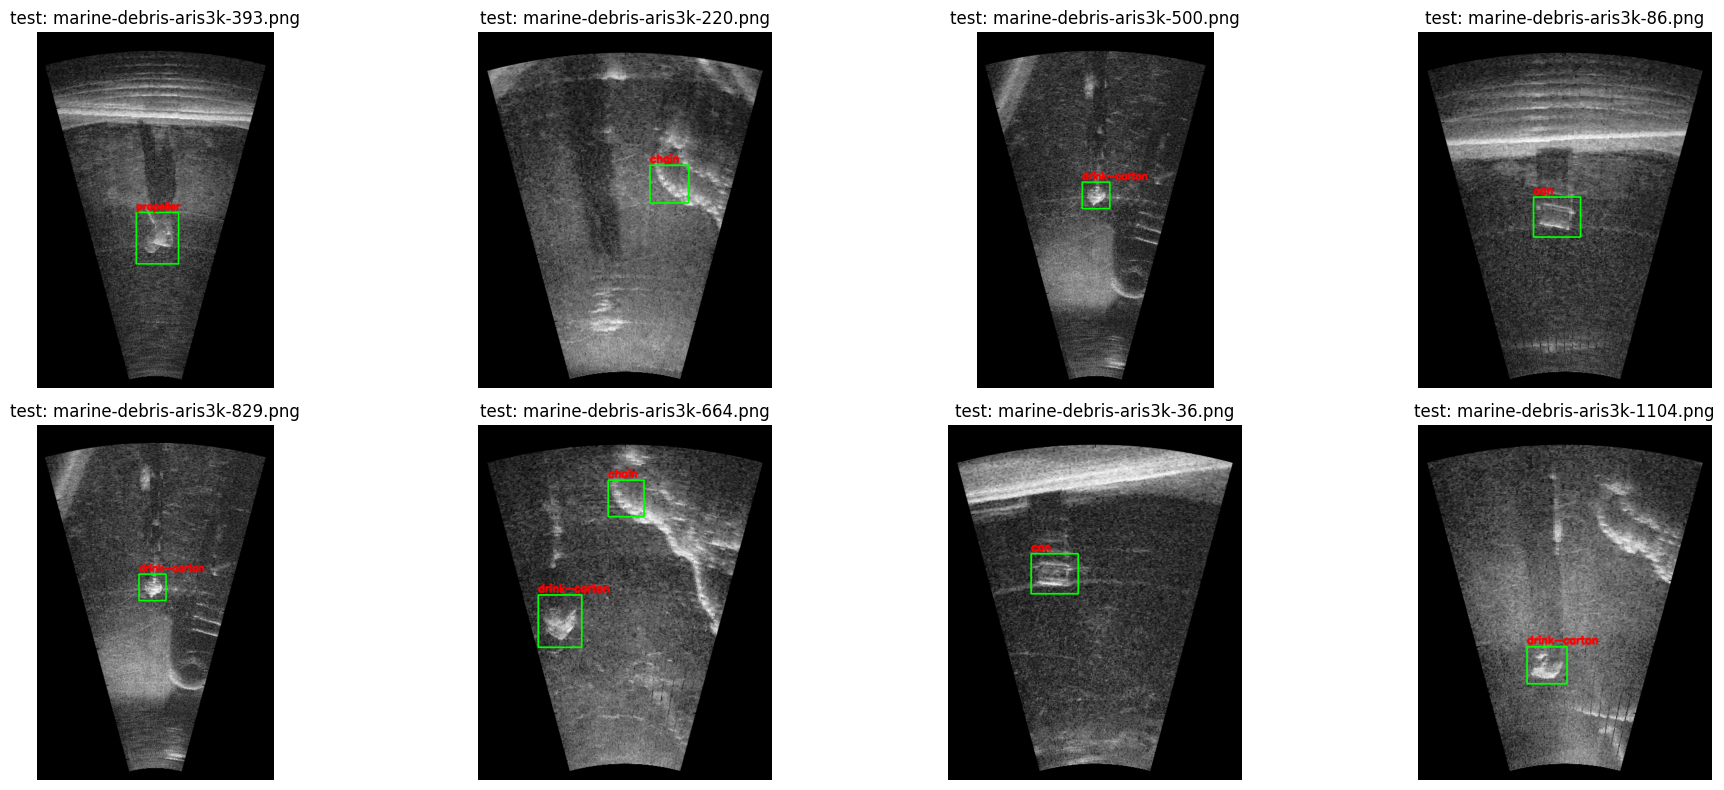

In [14]:
# VISUALIZATION

from pathlib import Path
import sys

DATA_PROCESSING_ROOT = Path.cwd().resolve().parents[1] 
sys.path.insert(0, str(DATA_PROCESSING_ROOT))


from utils.yolo_viz import load_yolo_dataset_yaml, show_random_labeled_images

ds = load_yolo_dataset_yaml("fls_marine_debris.yaml")  # yaml is next to the notebook

split = "test"  # train / val / test
img_dir = {"train": ds.train, "val": ds.val, "test": ds.test}[split]

show_random_labeled_images(
    images_split_dir=img_dir,
    names=ds.names,
    num_pics=8,
    cols=4,
    require_labels=True,
   
    title_prefix=f"{split}: ",
)
